In [1]:
!pip install prophet
!pip install statsmodels

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

from data_utils import *
from eda_utils import *
from preprocessing import *
from models import *
from evaluation import *
from anomaly_detection import *
from visualization import *
from time_series_models import *

In [3]:
## Загрузка данных

df = load_data("c2k_data_comma.csv")

basic_info(df)

df.head()

Dataset shape: (3943, 98)

Columns:
Index(['nr', 'i1_legid', 'i1_rcs_p', 'i1_rcs_e', 'i1_dep_1_p', 'i1_dep_1_e',
       'i1_dep_1_place', 'i1_rcf_1_p', 'i1_rcf_1_e', 'i1_rcf_1_place',
       'i1_dep_2_p', 'i1_dep_2_e', 'i1_dep_2_place', 'i1_rcf_2_p',
       'i1_rcf_2_e', 'i1_rcf_2_place', 'i1_dep_3_p', 'i1_dep_3_e',
       'i1_dep_3_place', 'i1_rcf_3_p', 'i1_rcf_3_e', 'i1_rcf_3_place',
       'i1_dlv_p', 'i1_dlv_e', 'i1_hops', 'i2_legid', 'i2_rcs_p', 'i2_rcs_e',
       'i2_dep_1_p', 'i2_dep_1_e', 'i2_dep_1_place', 'i2_rcf_1_p',
       'i2_rcf_1_e', 'i2_rcf_1_place', 'i2_dep_2_p', 'i2_dep_2_e',
       'i2_dep_2_place', 'i2_rcf_2_p', 'i2_rcf_2_e', 'i2_rcf_2_place',
       'i2_dep_3_p', 'i2_dep_3_e', 'i2_dep_3_place', 'i2_rcf_3_p',
       'i2_rcf_3_e', 'i2_rcf_3_place', 'i2_dlv_p', 'i2_dlv_e', 'i2_hops',
       'i3_legid', 'i3_rcs_p', 'i3_rcs_e', 'i3_dep_1_p', 'i3_dep_1_e',
       'i3_dep_1_place', 'i3_rcf_1_p', 'i3_rcf_1_e', 'i3_rcf_1_place',
       'i3_dep_2_p', 'i3_dep_2_e', 'i3_dep_2_

,nr,i1_legid,i1_rcs_p,i1_rcs_e,i1_dep_1_p,i1_dep_1_e,i1_dep_1_place,i1_rcf_1_p,i1_rcf_1_e,i1_rcf_1_place,...,o_dep_3_p,o_dep_3_e,o_dep_3_place,o_rcf_3_p,o_rcf_3_e,o_rcf_3_place,o_dlv_p,o_dlv_e,o_hops,legs
0,0.0,5182.0,199.0,218.0,210.0,215.0,609.0,935.0,736.0,256.0,...,?,?,?,?,?,?,780.0,434.0,1.0,2.0
1,1.0,6523.0,844.0,584.0,90.0,297.0,700.0,1935.0,1415.0,431.0,...,?,?,?,?,?,?,3870.0,445.0,1.0,2.0
2,2.0,5878.0,4380.0,4119.0,90.0,280.0,456.0,905.0,547.0,700.0,...,?,?,?,?,?,?,550.0,1520.0,1.0,1.0
3,3.0,1275.0,759.0,169.0,240.0,777.0,173.0,340.0,577.0,349.0,...,?,?,?,?,?,?,3780.0,159.0,1.0,1.0
4,4.0,8117.0,1597.0,1485.0,150.0,241.0,411.0,585.0,612.0,128.0,...,?,?,?,?,?,?,4140.0,4797.0,2.0,1.0


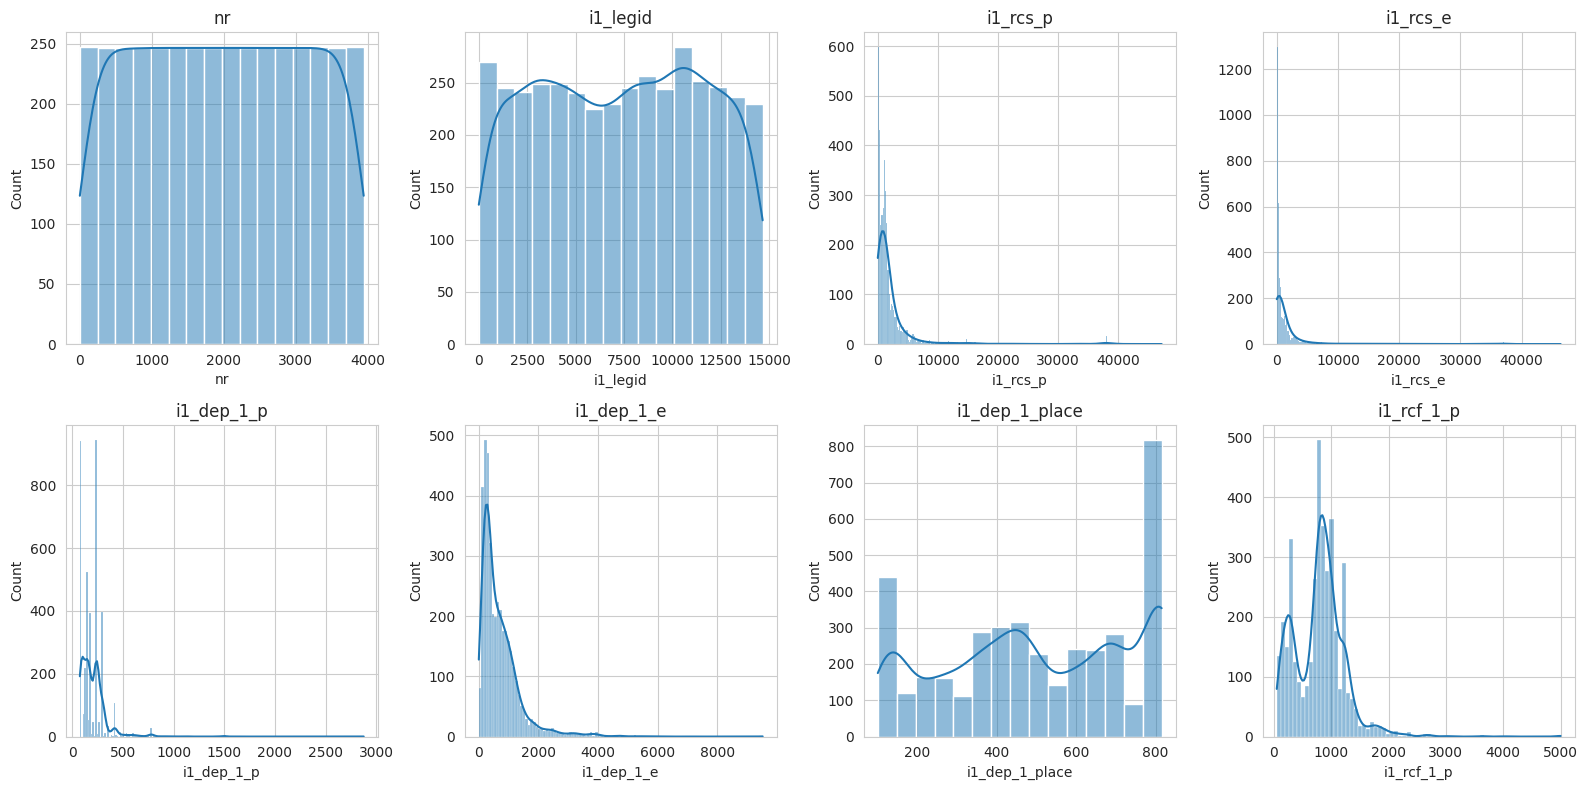

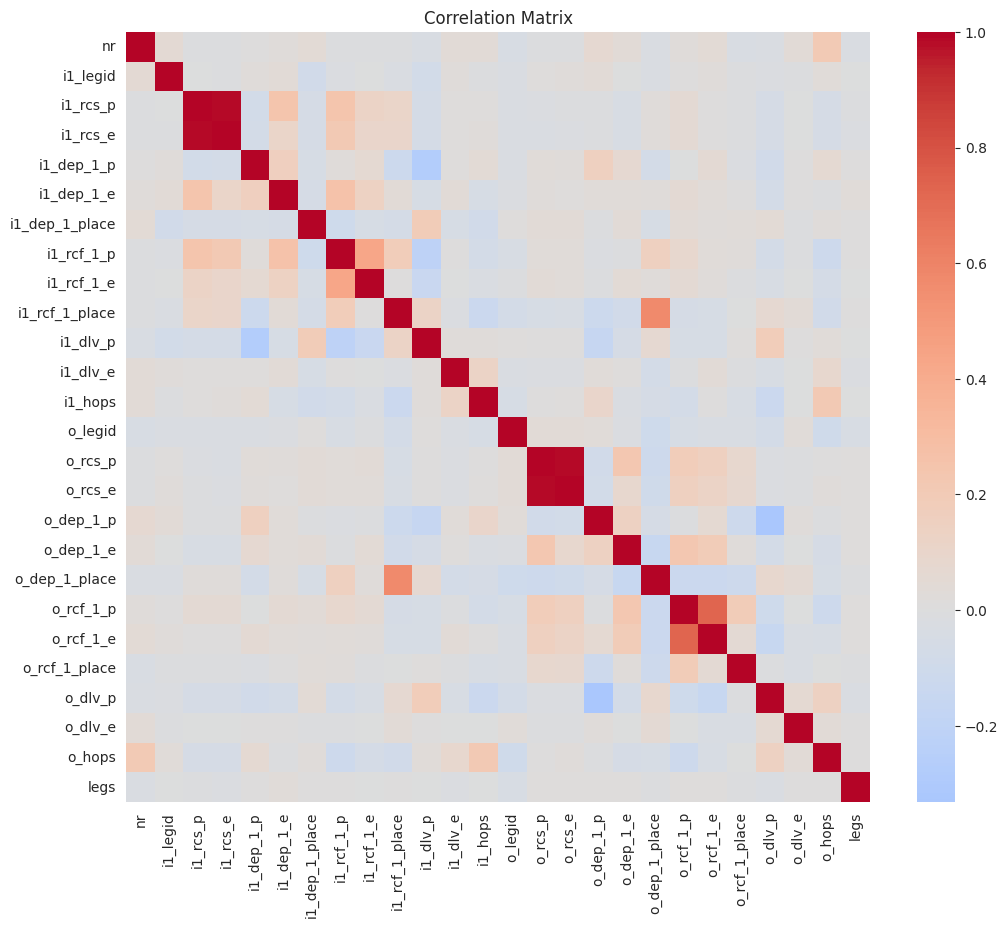

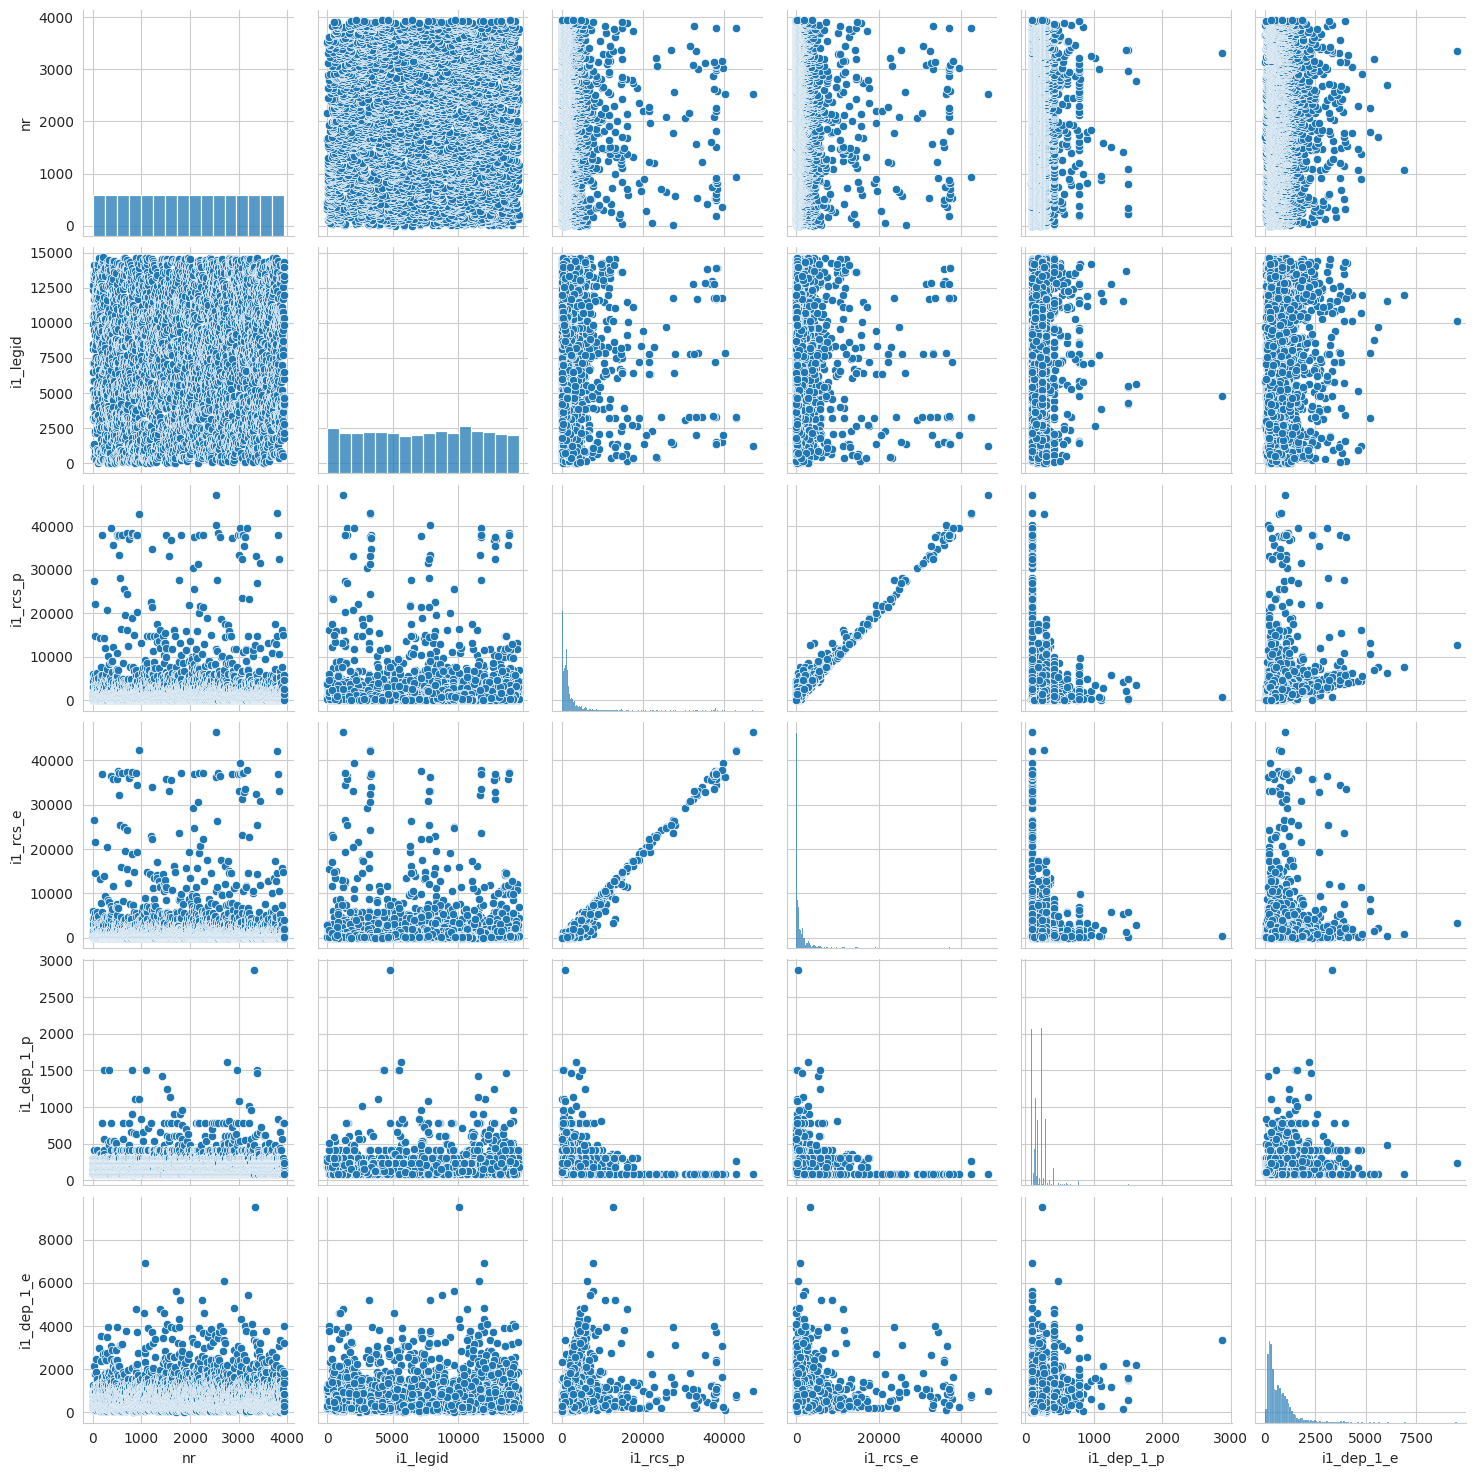

In [4]:
## EDA

plot_top_distributions(df)

plot_correlation(df)

pairplot_features(df)


# На первом этапе был проведён Exploratory Data Analysis (EDA).

На гистограммах показано распределение ключевых переменных логистического процесса — таких как время отправки, время прибытия и различные этапы обработки груза.

Видно, что большинство временных показателей имеют сильно асимметричное распределение с длинным хвостом. Это означает, что большинство доставок происходит быстро, но существует небольшое количество случаев с очень большими задержками.

**Главный вывод:**

**Данные содержат выбросы и имеют не нормальное распределение.**


# Далее был построен pairplot, который показывает попарные зависимости между несколькими числовыми признаками.

Это позволяет визуально определить возможные корреляции между этапами логистического процесса.

На графиках можно заметить, что некоторые переменные имеют линейную зависимость, особенно между прогнозируемыми и фактическими временными метками.

**Вывод:**

**Некоторые признаки сильно связаны между собой.**

# Для более точного анализа зависимостей была построена матрица корреляций.

Она показывает коэффициенты корреляции между всеми числовыми признаками датасета.

Видно, что между некоторыми этапами доставки существует высокая положительная корреляция, что логично — задержка на одном этапе логистики может влиять на последующие этапы.

**Вывод:**

**Этапы доставки взаимосвязаны.**

In [5]:
## preprocessing

df = encode_categorical(df)

df = fill_missing(df)

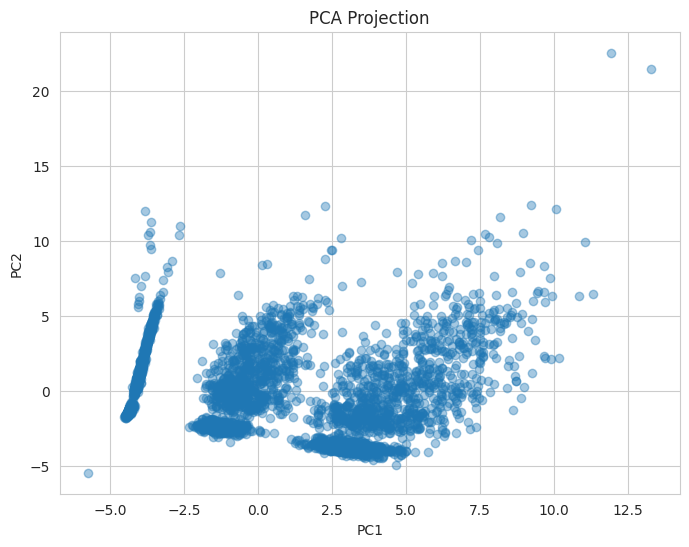

In [6]:
## PCA после preprocessing

pca_visualization(df)

# PCA (снижение размерности)

Далее была применена методика PCA — Principal Component Analysis.
Этот метод позволяет снизить размерность данных и визуализировать структуру датасета в двумерном пространстве.

На графике каждая точка представляет одну перевозку.
Мы видим несколько кластеров наблюдений, что говорит о наличии различных типов логистических процессов или маршрутов.

# Вывод:

**В данных присутствуют разные типы перевозок.**

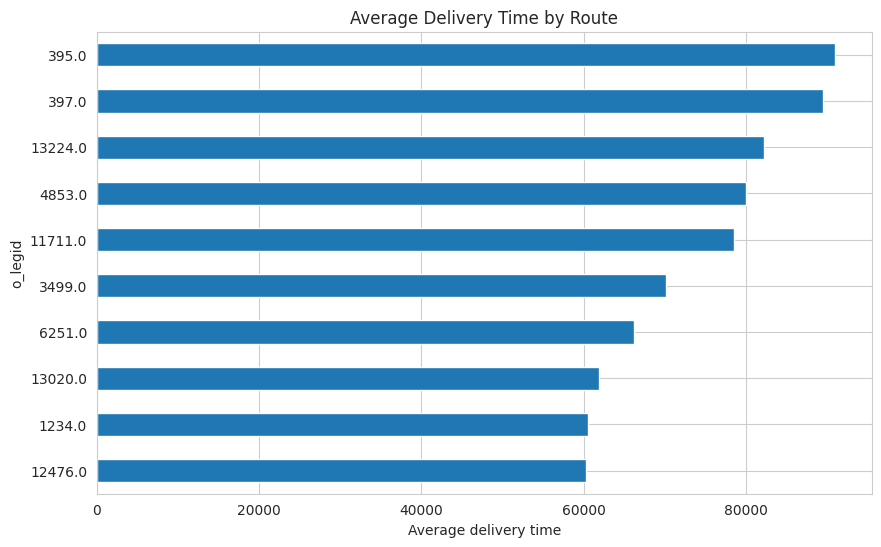

In [7]:
## Анализ логистических маршрутов

plt.figure(figsize=(10,6))

df.groupby("o_legid")["i1_dlv_e"].mean().sort_values().tail(10).plot(kind="barh")

plt.title("Average Delivery Time by Route")

plt.xlabel("Average delivery time")

plt.show()

# Для анализа логистической эффективности я построил график среднего времени доставки по маршрутам.

На графике видно, что некоторые маршруты имеют значительно большее среднее время доставки, чем остальные.
Это может быть связано с географическими факторами, количеством пересадок или сложностью маршрута.
Еденица измерения - минуты.
0_Legid - означает id определённого транспортного участка.

# Вывод:

**Некоторые маршруты значительно менее эффективны.**

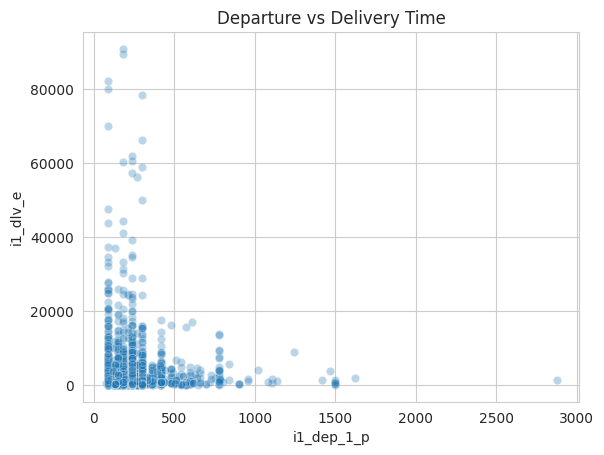

In [8]:
## Зависимость этапов доставки

sns.scatterplot(
    data=df,
    x="i1_dep_1_p",
    y="i1_dlv_e",
    alpha=0.3
)

plt.title("Departure vs Delivery Time")

plt.show()

# Scatter: Departure vs Delivery Time

**Далее была исследована зависимость между временем отправки и временем доставки.**

На scatter-графике видно, что в большинстве случаев увеличение времени отправки приводит к увеличению общего времени доставки, однако присутствует большой разброс значений.

Это говорит о том, что на итоговое время доставки влияют не только время отправки, но и другие факторы логистической цепочки.

# Вывод:

**Delivery time/Время доставки зависит от нескольких факторов.**

In [9]:
## Подготовка данных

y = df["i1_dlv_e"]

X = df.drop(columns=["i1_dlv_e"])

In [10]:
## train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [11]:
## обучение ML моделей

models = train_models(X_train, y_train)

Мы использовали 5 моделей:

Linear Regression

Decision Tree

Random Forest

SVR

Gradient Boosting

Все из библиотеки
scikit-learn.

Далее была решена задача прогнозирования времени доставки с использованием нескольких моделей машинного обучения.

Было обучено 5 различных моделей, чтобы сравнить их качество.

In [12]:
## Оценка моделей

errors = []

for name, model in models.items():

    mae, rmse, pred = evaluate_model(model, X_test, y_test)

    print(name, "MAE:", mae, "RMSE:", rmse)

    errors.append(mae)

LinearRegression MAE: 2880.9563730262103 RMSE: 5427.846888872371
DecisionTree MAE: 4142.3688212927755 RMSE: 9480.517928836274
RandomForest MAE: 3058.9323447401775 RMSE: 5357.189329755779
SVR MAE: 2329.44336610896 RMSE: 5703.223139253443
GradientBoosting MAE: 2754.439254266436 RMSE: 5319.660219420439


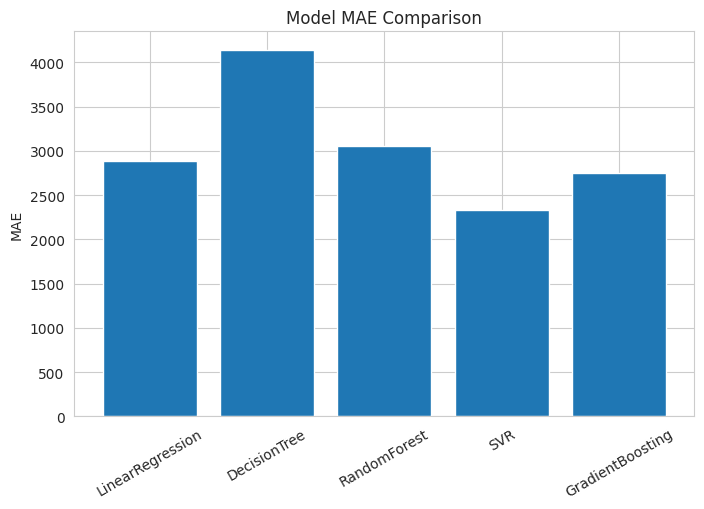

In [13]:
## График ошибок

plot_model_errors(models.keys(), errors)

# Для оценки качества моделей использовались метрики MAE и RMSE.

MAE показывает среднюю абсолютную ошибку предсказания.

Результаты:

Model	MAE
Linear Regression	~2880
Decision Tree	~4041
Random Forest	~3142
SVR	~2329
Gradient Boosting	~2773

# Вывод:

**Лучший результат показала модель SVR, которая имеет наименьшую среднюю ошибку предсказания.**

In [15]:
## ARIMA

series = df["i1_dlv_e"]

arima_model = train_arima(series)

forecast = forecast_arima(arima_model, 50)

forecast

,predicted_mean
3943,2565.119941
3944,2564.624653
3945,2550.968974
3946,2563.812738
3947,2551.849773
3948,2562.991308
3949,2552.614809
3950,2562.278804
3951,2553.278389
3952,2561.660789


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


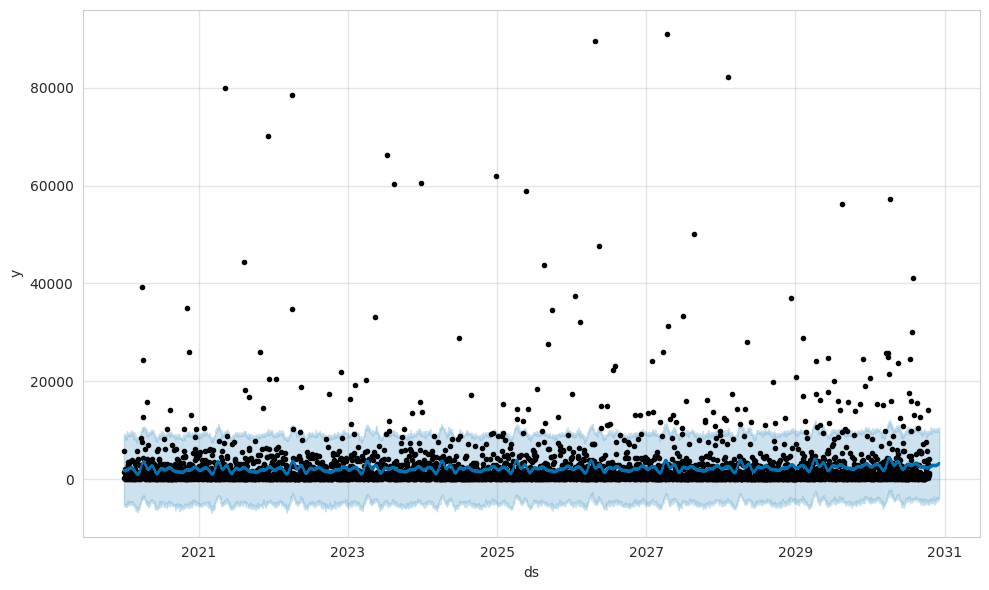

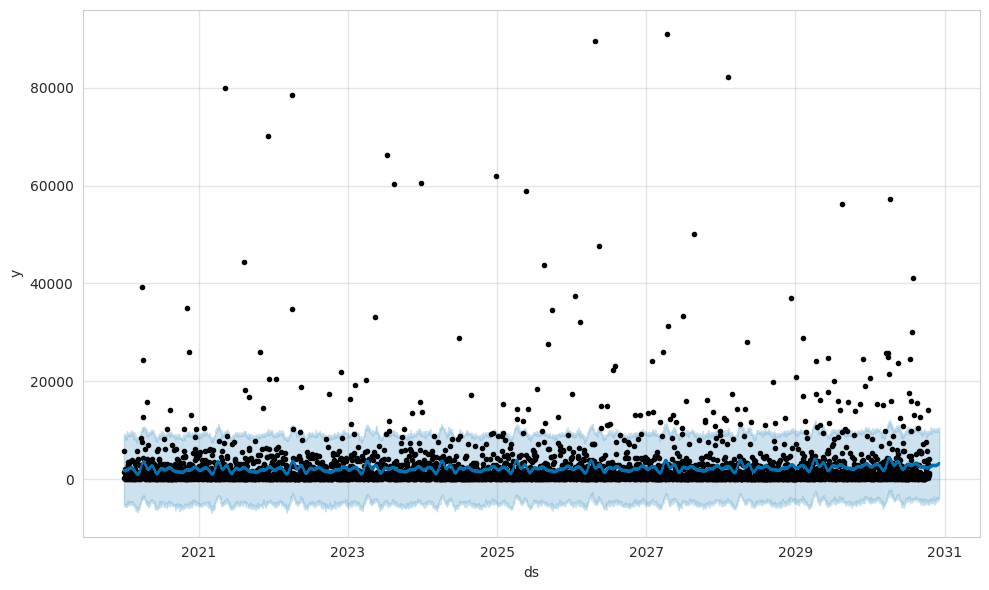

In [17]:
## Prophet

series = df["i1_dlv_e"]

prophet_model, df_prophet = train_prophet(series)

forecast_prophet_df = forecast_prophet(prophet_model, df_prophet, 50)

prophet_model.plot(forecast_prophet_df)

# Time Series — Prophet

**Используется Prophet.**

Также была использована модель Prophet, которая специально разработана для анализа временных рядов.

Она автоматически учитывает тренды и сезонность в данных.

**На графике:**

чёрные точки — реальные данные

синяя линия — прогноз

голубая область — доверительный интервал

# Вывод:

**Prophet позволяет прогнозировать динамику логистических показателей.**

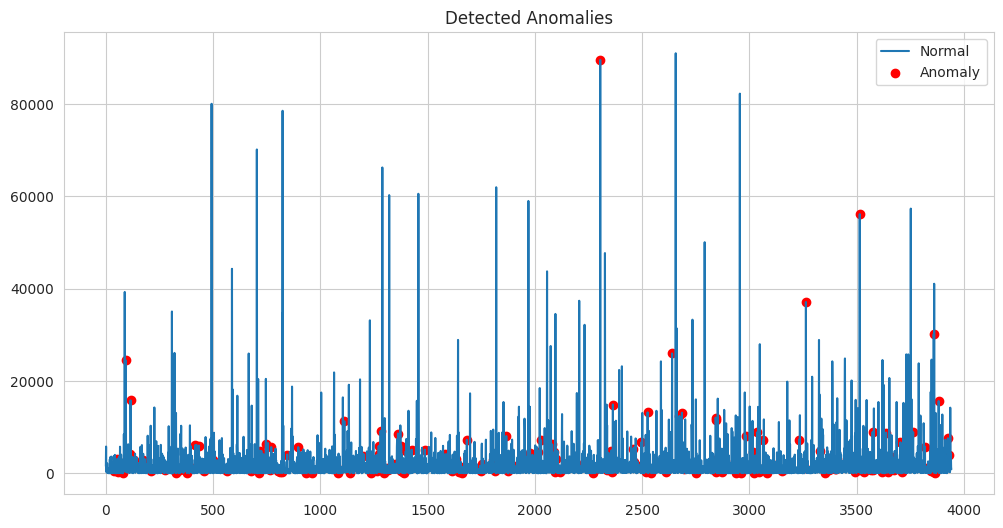

In [18]:
## Обнаружение аномалий

labels = detect_anomalies(X)

plot_anomalies(df["i1_dlv_e"], labels)

# Для обнаружения аномалий используется алгоритм Isolation Forest.

Для обнаружения аномалий был применён алгоритм Isolation Forest.
Он позволяет находить редкие и необычные наблюдения в данных.

На графике красными точками отмечены аномальные доставки, которые значительно отличаются от большинства значений.

Такие аномалии могут соответствовать серьёзным задержкам, ошибкам в логистике или нестандартным маршрутам.

# Вывод:

**Алгоритм успешно обнаруживает необычные доставки.**

In [19]:
## подготовка ARIMA данных

from statsmodels.tsa.arima.model import ARIMA

series = df["i1_dlv_e"]

train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

arima_model = ARIMA(train, order=(2,1,2)).fit()

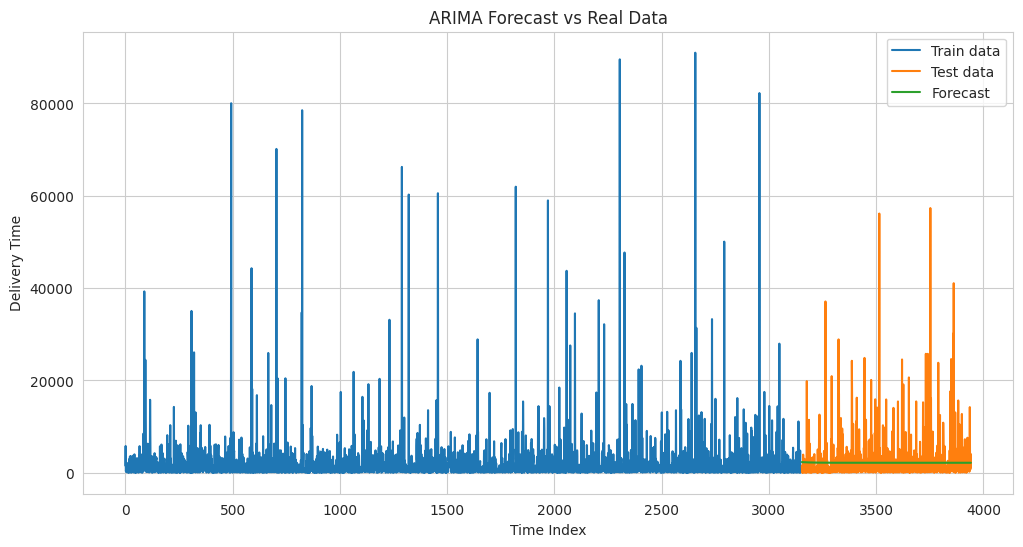

In [20]:
## Train / Test / Forecast график

forecast = arima_model.forecast(steps=len(test))

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train data")
plt.plot(test.index, test, label="Test data")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast vs Real Data")

plt.xlabel("Time Index")
plt.ylabel("Delivery Time")

plt.legend()

plt.show()

# Первый график ARIMA Forecast vs Real Data

На графике показано сравнение реальных данных и прогноза модели.

Линии:

Синяя линия — Train data

Это:

обучающая часть временного ряда

То есть 80% данных, на которых обучалась ARIMA.

По оси X:

Time Index

Это порядковый номер наблюдения в датасете.

По оси Y:

Delivery Time

Это время доставки (в минутах) из признака:

i1_dlv_e

Оранжевая линия — Test data

Это:

реальные значения

которые модель не видела при обучении.

Эти данные используются чтобы проверить:

насколько хорошо модель прогнозирует будущее

Зелёная линия — Forecast

Это:

прогноз ARIMA

То есть значения, которые модель предсказала для тестовой части.

Что видно на графике

В обучающей части наблюдаются очень большие выбросы

Например:

20000
40000
80000

Это говорит о том, что в данных есть:

аномально долгие доставки

что логично для логистики.

В тестовой части значения тоже сильно скачут

То есть временной ряд:

очень шумный

Прогноз ARIMA почти плоский

Зелёная линия держится примерно около:

2000–3000

Это происходит потому что ARIMA:

аппроксимирует среднее поведение ряда

и не может предсказать резкие скачки.

# Вывод по первому графику:

**Модель ARIMA хорошо аппроксимирует общий уровень временного ряда, однако из-за высокой волатильности данных она не может точно предсказывать резкие всплески времени доставки.**

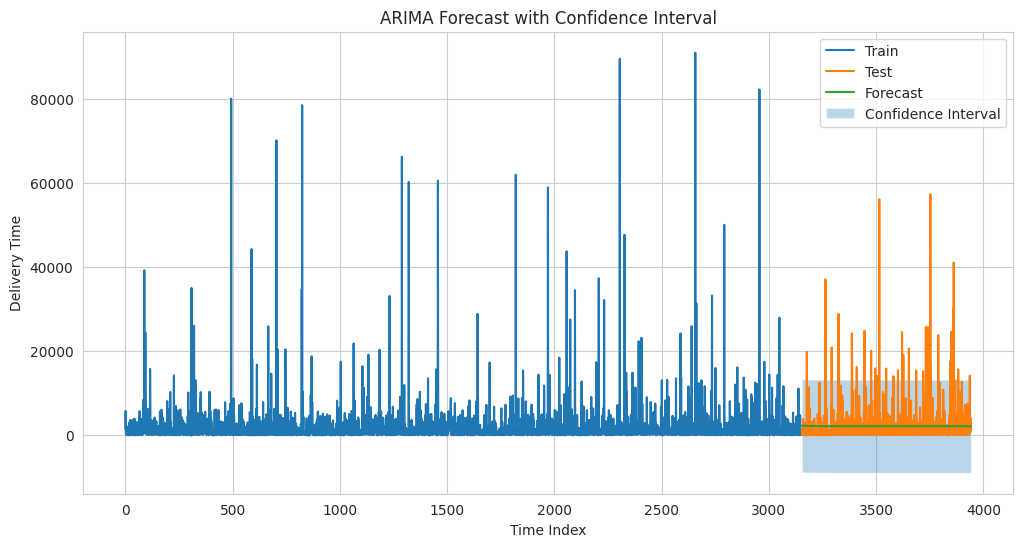

In [21]:
## Confidence Interval график

forecast_result = arima_model.get_forecast(steps=len(test))

forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

forecast_mean.index = test.index
conf_int.index = test.index

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")

plt.plot(test.index, forecast_mean, label="Forecast")

plt.fill_between(
    test.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("ARIMA Forecast with Confidence Interval")

plt.xlabel("Time Index")
plt.ylabel("Delivery Time")

plt.legend()

plt.show()

# ARIMA Forecast with Confidence Interval

Этот график показывает тот же прогноз, но добавляет доверительный интервал.

Линии

Train

обучающие данные

Test

реальные тестовые значения

Forecast

прогноз модели

Серая область
Confidence Interval

Это:

доверительный интервал прогноза

Он показывает диапазон:

в котором модель ожидает реальные значения

обычно это:

95% confidence interval
Что видно на графике

Серая область:

примерно от -8000 до +12000

Это означает:

модель предполагает, что реальные значения будут находиться в этом диапазоне.

Но реальные значения иногда доходят до:

60000

Поэтому они выходят за пределы интервала.

Это говорит о том, что:

данные имеют очень высокую дисперсию

и временной ряд:

сильно шумный
Почему ARIMA плохо ловит пики

# Модель ARIMA хорошо работает, когда ряд:

стационарный

и имеет:

тренд + сезонность

# Но у меня данные с большим количеством случайных выбросов

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

## Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

## Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

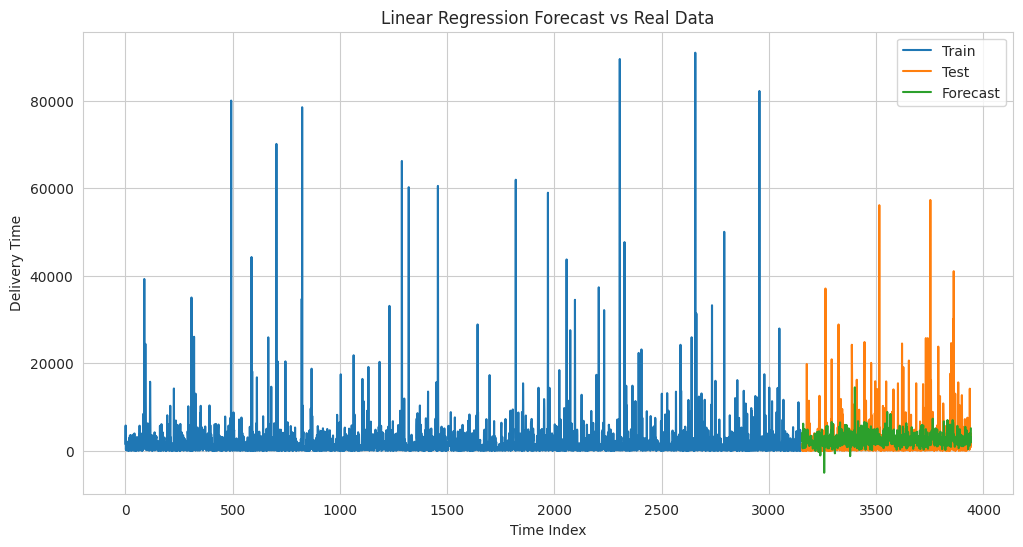

In [29]:
## Linear Regression: Train vs Test vs Forecast

lr_pred = lr.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(y_train.values, label="Train")

plt.plot(
    range(len(y_train), len(y_train)+len(y_test)),
    y_test.values,
    label="Test"
)

plt.plot(
    range(len(y_train), len(y_train)+len(y_test)),
    lr_pred,
    label="Forecast"
)

plt.title("Linear Regression Forecast vs Real Data")

plt.xlabel("Time Index")
plt.ylabel("Delivery Time")

plt.legend()

plt.show()

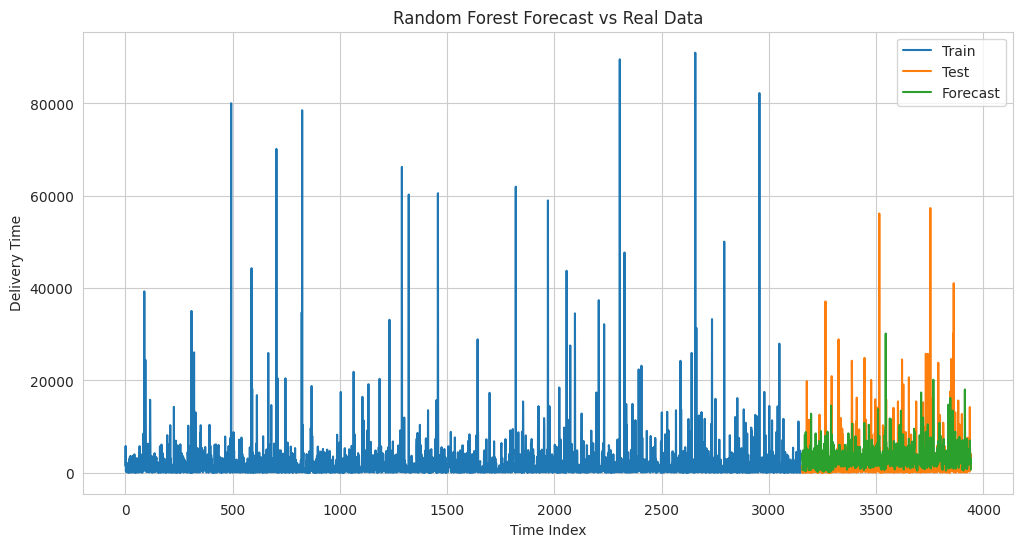

In [30]:
## Random Forest: Train vs Test vs Forecast

rf_pred = rf.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(y_train.values, label="Train")

plt.plot(
    range(len(y_train), len(y_train)+len(y_test)),
    y_test.values,
    label="Test"
)

plt.plot(
    range(len(y_train), len(y_train)+len(y_test)),
    rf_pred,
    label="Forecast"
)

plt.title("Random Forest Forecast vs Real Data")

plt.xlabel("Time Index")
plt.ylabel("Delivery Time")

plt.legend()

plt.show()

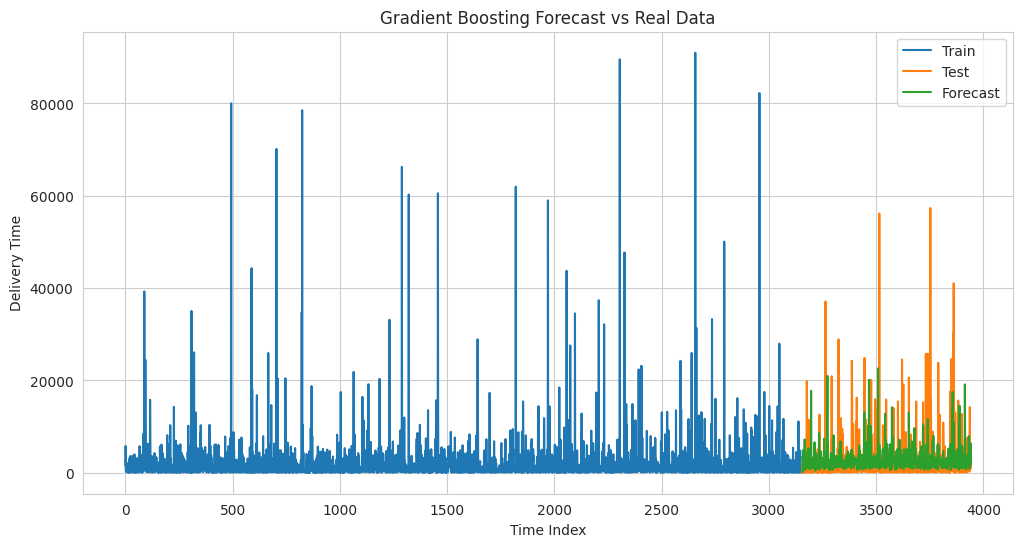

In [31]:
## Gradient Boosting: Train vs Test vs Forecast

gb_pred = gb.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(y_train.values, label="Train")

plt.plot(
    range(len(y_train), len(y_train)+len(y_test)),
    y_test.values,
    label="Test"
)

plt.plot(
    range(len(y_train), len(y_train)+len(y_test)),
    gb_pred,
    label="Forecast"
)

plt.title("Gradient Boosting Forecast vs Real Data")

plt.xlabel("Time Index")
plt.ylabel("Delivery Time")

plt.legend()

plt.show()

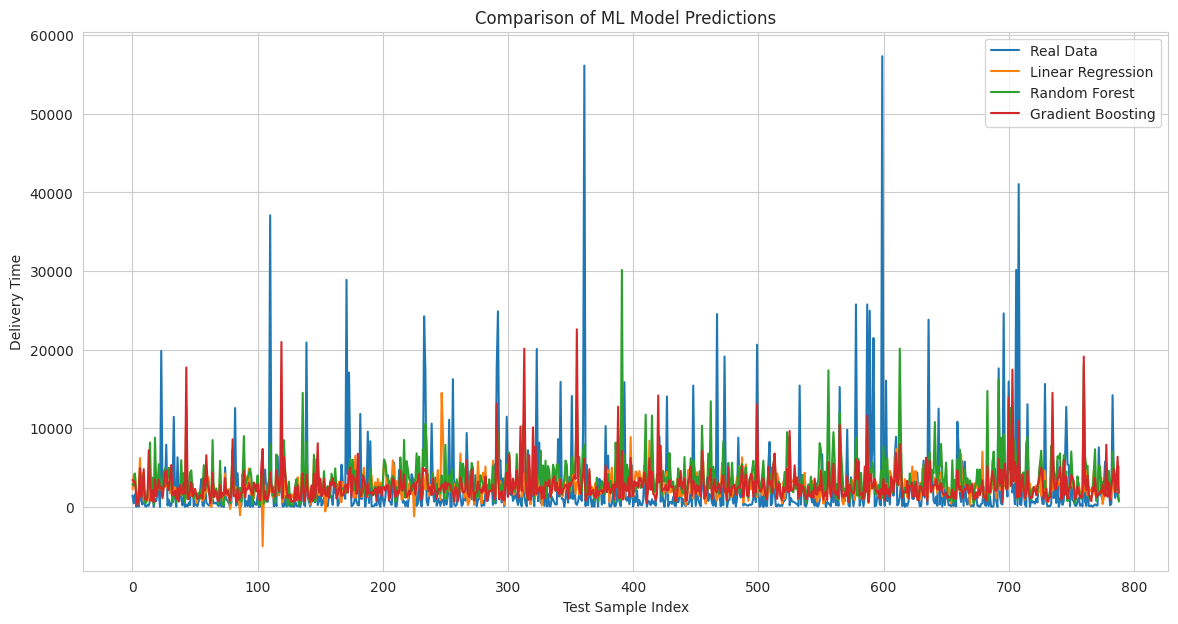

In [32]:
## Comparison of ML Models

plt.figure(figsize=(14,7))

plt.plot(y_test.values, label="Real Data")

plt.plot(lr_pred, label="Linear Regression")
plt.plot(rf_pred, label="Random Forest")
plt.plot(gb_pred, label="Gradient Boosting")

plt.title("Comparison of ML Model Predictions")

plt.xlabel("Test Sample Index")
plt.ylabel("Delivery Time")

plt.legend()

plt.show()

# Сравнение моделей

В работе были применены различные подходы прогнозирования: модели машинного обучения (Linear Regression, Random Forest, Gradient Boosting) и методы анализа временных рядов (ARIMA).

По результатам визуализации видно, что все модели сталкиваются с трудностью прогнозирования экстремальных значений времени доставки. Данные содержат большое количество выбросов и характеризуются высокой волатильностью.

Модель ARIMA демонстрирует сглаженный прогноз и не способна предсказывать резкие всплески значений. Это связано с тем, что ARIMA ориентируется на автокорреляции временного ряда и предполагает относительную стационарность данных.

Модели машинного обучения показывают более гибкое поведение, поскольку используют дополнительные признаки и способны частично адаптироваться к сложной структуре данных. Среди них наиболее стабильные результаты демонстрируют ансамблевые методы Random Forest и Gradient Boosting.

Таким образом, для данного датасета логистических перевозок методы машинного обучения оказываются более эффективными, чем классические модели временных рядов.

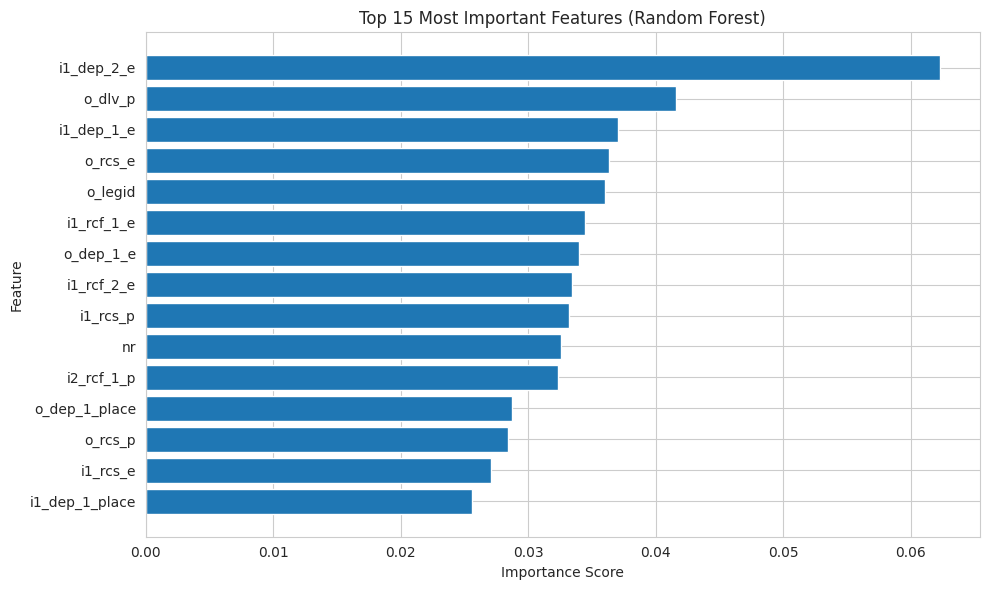

In [33]:
## Важность признаков (Top 15)

import pandas as pd
import matplotlib.pyplot as plt

rf_model = models["RandomForest"]

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Анализ важности признаков

**График Feature Importance показывает 15 признаков, которые оказывают наибольшее влияние на прогноз времени доставки согласно модели Random Forest.**

Из результатов видно, что наибольший вклад в предсказание времени доставки вносят признаки, связанные с различными этапами маршрута перевозки. В частности, наиболее важными оказались параметры:

i1_dep_2_e

o_dlv_p

i1_dep_1_e

o_rcs_e

o_legid

Это указывает на то, что характеристики отдельных этапов транспортировки и параметры маршрута оказывают существенное влияние на итоговое время доставки.

Также можно заметить, что значительное количество важных признаков относится к промежуточным логистическим операциям (например, этапам отправления и обработки груза). Это подтверждает, что время доставки зависит не только от конечной точки маршрута, но и от эффективности обработки груза на различных этапах логистической цепочки.

Таким образом, анализ важности признаков показывает, что ключевую роль в прогнозировании времени доставки играют параметры, описывающие структуру маршрута и отдельные стадии логистического процесса.


**Полученные результаты демонстрируют, что временные задержки в логистике в большей степени связаны с отдельными этапами транспортировки, чем с общими характеристиками маршрута.**

